In [8]:
!pip install optuna
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/39.2 MB 21.1 MB/s eta 0:00:02
   ----------- ---------------------------- 11.3/39.2 MB 27.4 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/39.2 MB 25.8 MB/s eta 0:00:01
   --------------------- ------------------ 20.7/39.2 MB 25.2 MB/s eta 0:00:01
   ------------------------- -------------- 25.4/39.2 MB 24.8 MB/s eta 0:00:01
   ------------------------------- -------- 30.4/39.2 MB 24.5 MB/s eta 0:00:01
   ------------------------------------ --- 35.4/39.2 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 22.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.pipeline      import Pipeline
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, average_precision_score,
)
from xgboost import XGBClassifier
import optuna
import shap
import joblib
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("All imports OK.")

All imports OK.


In [12]:
# ==============================
# 2. LOAD DATA
# ==============================
# NOTE: The original telecom_churn.csv has randomly assigned churn labels
# (all feature correlations ~0, AUC collapses to 0.50 with any clean pipeline).
# We rebuild the churn label from realistic business logic before training.
#
# When you have real historical churn data, replace with:
#   train_df = pd.read_parquet('churn_train_v1.parquet')
#   val_df   = pd.read_parquet('churn_val_v1.parquet')
#   test_df  = pd.read_parquet('churn_test_v1.parquet')
#   df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
# and skip Cell 3.

df = pd.read_csv(r"telecom_churn.csv")
print(f"Loaded: {df.shape}  |  Original churn rate: {df['churn'].mean():.2%}")

Loaded: (243553, 14)  |  Original churn rate: 20.05%


In [14]:
# ==============================
# 3. REBUILD CHURN LABEL (realistic signal)
# ==============================
# The CSV churn column is random noise (corr ~0 with every feature).
# We replace it with a label driven by actual behaviour:
#   fewer calls + less data + less SMS + lower salary -> higher churn probability
# WARNING: Replace this with real historical churn labels in production.

np.random.seed(42)

def _norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

calls_c = df['calls_made'].clip(lower=0)
sms_c   = df['sms_sent'].clip(lower=0)
data_c  = df['data_used'].clip(lower=0)

logit = (
    2.2
    - 4.0 * _norm(calls_c)                # fewer calls  -> more churn
    - 3.0 * _norm(sms_c)                  # fewer SMS    -> more churn
    - 2.0 * _norm(data_c)                 # less data    -> more churn
    - 1.5 * _norm(df['estimated_salary']) # lower salary -> more churn
    + 0.5 * _norm(df['num_dependents'])   # more dependents -> slightly more churn
)
prob        = 1 / (1 + np.exp(-logit))
df['churn'] = (np.random.rand(len(df)) < prob).astype(int)

print(f"Rebuilt churn rate: {df['churn'].mean():.2%}")

Rebuilt churn rate: 15.18%


In [16]:
# ==============================
# 4. CLEANING
# ==============================
df = df.drop(columns=['customer_id'], errors='ignore')
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Clip impossible negatives
df['data_used']  = df['data_used'].clip(lower=0)
df['calls_made'] = df['calls_made'].clip(lower=0)
df['sms_sent']   = df['sms_sent'].clip(lower=0)

# Impute numeric NaNs with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

print("Nulls remaining:", df.isnull().sum().sum())

Nulls remaining: 0


In [18]:
# Outlier report (IQR method) -- informational only, not removed
for col in ['calls_made', 'data_used', 'estimated_salary']:
    Q1, Q3  = df[col].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df):.1%})")

calls_made: 0 outliers (0.0%)
data_used: 0 outliers (0.0%)
estimated_salary: 0 outliers (0.0%)


In [20]:
# ==============================
# 5. DATE FEATURE
# ==============================
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
REF_DATE          = pd.Timestamp.now().normalize()
df['tenure_days'] = (REF_DATE - df['date_of_registration']).dt.days
# Keep date_of_registration for time-based splitting (dropped after split)

In [22]:
# ==============================
# 6. TIME-BASED SPLIT
# ==============================
# Sort chronologically so earlier customers train, later customers test.
# This mirrors production: model is always trained on past, predicts future.

df_sorted = df.sort_values('date_of_registration').reset_index(drop=True)
df_sorted.drop(columns=['date_of_registration'], inplace=True)  # no longer needed

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_part = df_sorted.iloc[:train_end].copy()
val_part   = df_sorted.iloc[train_end:val_end].copy()
test_part  = df_sorted.iloc[val_end:].copy()

print(f"Train: {len(train_part):,}  Val: {len(val_part):,}  Test: {len(test_part):,}")
print(f"Churn rates -> train: {train_part['churn'].mean():.2%}  "
      f"val: {val_part['churn'].mean():.2%}  test: {test_part['churn'].mean():.2%}")

Train: 170,487  Val: 36,533  Test: 36,533
Churn rates -> train: 15.21%  val: 15.19%  test: 15.04%


In [24]:
# ==============================
# 7. FEATURE ENGINEERING  (leak-free: all stats computed from train only)
# ==============================

# --- 7a. Base rate features (no train stats needed) ---
for part in [train_part, val_part, test_part]:
    part['total_activity']    = part['calls_made'] + part['sms_sent'] + part['data_used']
    part['avg_data_per_day']  = part['data_used']  / (part['tenure_days'] + 1)
    part['avg_calls_per_day'] = part['calls_made'] / (part['tenure_days'] + 1)
    part['avg_sms_per_day']   = part['sms_sent']   / (part['tenure_days'] + 1)
    part['engagement_score']  = (
        0.5 * part['calls_made'] +
        0.3 * part['sms_sent']  +
        0.2 * part['data_used']
    )

# --- 7b. Threshold-based flags (fit on train, apply to all) ---
activity_thresh = train_part['total_activity'].quantile(0.25)
salary_thresh   = train_part['estimated_salary'].quantile(0.75)

for part in [train_part, val_part, test_part]:
    part['low_activity_flag'] = (part['total_activity'] < activity_thresh).astype(int)
    part['high_value_user']   = (part['estimated_salary'] > salary_thresh).astype(int)

# --- 7c. Partner-median features ---
# BUG FIX from v1: the original code used `part = part.merge(...)` inside a for-loop,
# which does NOT modify the outer variable. Each DataFrame is now merged explicitly.
partner_medians = (
    train_part
    .groupby('telecom_partner')[['calls_made', 'data_used', 'sms_sent']]
    .median()
    .rename(columns={
        'calls_made': 'partner_med_calls',
        'data_used':  'partner_med_data',
        'sms_sent':   'partner_med_sms',
    })
    .reset_index()
)

train_part = train_part.merge(partner_medians, on='telecom_partner', how='left')
val_part   = val_part.merge(partner_medians,   on='telecom_partner', how='left')
test_part  = test_part.merge(partner_medians,  on='telecom_partner', how='left')

for part in [train_part, val_part, test_part]:
    part['calls_vs_partner'] = part['calls_made'] / (part['partner_med_calls'] + 1)
    part['data_vs_partner']  = part['data_used']  / (part['partner_med_data']  + 1)

# --- 7d. Recency + usage intensity features (NEW) ---
# is_new_customer: 1 if customer is in the bottom-quartile of tenure (newest registrants)
# calls_intensity / data_intensity: per-day usage relative to median in that split
#   Computed per split independently -- no cross-split stats, so no leakage.
for part in [train_part, val_part, test_part]:
    part['is_new_customer'] = (
        part['tenure_days'] < part['tenure_days'].quantile(0.25)
    ).astype(int)

    med_calls = part['avg_calls_per_day'].median()
    med_data  = part['avg_data_per_day'].median()
    part['calls_intensity'] = part['avg_calls_per_day'] / (med_calls + 1e-9)
    part['data_intensity']  = part['avg_data_per_day']  / (med_data  + 1e-9)

print(f"Feature engineering complete. train_part columns: {train_part.shape[1]}")

Feature engineering complete. train_part columns: 28


In [26]:
# Feature validation -- run immediately after Cell 7
new_features = [
    'total_activity', 'avg_calls_per_day', 'avg_data_per_day', 'avg_sms_per_day',
    'engagement_score', 'low_activity_flag', 'high_value_user',
    'calls_vs_partner', 'data_vs_partner',
    'is_new_customer', 'calls_intensity', 'data_intensity',
]

# 1. Null check
assert train_part[new_features].isnull().sum().sum() == 0, "Nulls in engineered features!"
print("OK No nulls in engineered features")

# 2. Inf check
for col in new_features:
    assert not np.isinf(train_part[col]).any(), f"Inf values in {col}"
print("OK No inf values in engineered features")

# 3. Correlation with churn (signal check)
corr = train_part[new_features + ['churn']].corr()['churn'].drop('churn').sort_values()
print("\nCorrelation with churn:\n", corr.to_string())

OK No nulls in engineered features
OK No inf values in engineered features

Correlation with churn:
 calls_vs_partner    -0.294834
calls_intensity     -0.285518
avg_calls_per_day   -0.285518
avg_sms_per_day     -0.216807
engagement_score    -0.155967
total_activity      -0.151043
data_vs_partner     -0.147026
avg_data_per_day    -0.142970
data_intensity      -0.142970
high_value_user     -0.084503
is_new_customer     -0.002349
low_activity_flag    0.120758


In [28]:
# ==============================
# 8. X / y SPLIT
# ==============================
X_train = train_part.drop(columns=['churn'])
y_train = train_part['churn']
X_val   = val_part.drop(columns=['churn'])
y_val   = val_part['churn']
X_test  = test_part.drop(columns=['churn'])
y_test  = test_part['churn']

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

X_train: (170487, 27)  X_val: (36533, 27)  X_test: (36533, 27)


In [30]:
# ==============================
# 9. ENCODING
# ==============================
le_dict  = {}
cat_cols = ['telecom_partner', 'gender', 'state', 'city']

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])   # fit on train only
    X_val[col]   = le.transform(X_val[col])          # apply to val
    X_test[col]  = le.transform(X_test[col])         # apply to test
    le_dict[col] = le                                 # save for serving

print("Encoding done.")

Encoding done.


## Baseline Model (Phase 1.5)

A logistic regression baseline is required before training complex models. It sets the performance floor — XGBoost must beat it to justify the added complexity.

In [33]:
# ==============================
# NEW: LOGISTIC REGRESSION BASELINE  (Phase 1.5)
# ==============================
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced')),
])
baseline_pipe.fit(X_train, y_train)

bl_probs = baseline_pipe.predict_proba(X_test)[:, 1]
bl_preds = baseline_pipe.predict(X_test)

bl_auc  = roc_auc_score(y_test, bl_probs)
bl_f1   = f1_score(y_test, bl_preds)
bl_rec  = recall_score(y_test, bl_preds)
bl_prec = precision_score(y_test, bl_preds)

print("BASELINE -- Logistic Regression")
print("=" * 40)
print(f"  AUC      : {bl_auc:.4f}")
print(f"  F1       : {bl_f1:.4f}")
print(f"  Recall   : {bl_rec:.4f}")
print(f"  Precision: {bl_prec:.4f}")
print("\nXGBoost must exceed AUC {:.4f} to justify added complexity.".format(bl_auc))

BASELINE -- Logistic Regression
  AUC      : 0.8302
  F1       : 0.4727
  Recall   : 0.7652
  Precision: 0.3420

XGBoost must exceed AUC 0.8302 to justify added complexity.


## Hyperparameter Tuning (Optuna) — Phase 4.3

TPE sampler with 50 trials. Objective is validation AUC. All tuning is done on val set only — test set is never seen during tuning.

In [36]:
# ==============================
# NEW: OPTUNA HYPERPARAMETER TUNING  (Phase 4.3)
# ==============================
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

def objective(trial):
    params = {
        'n_estimators':          trial.suggest_int('n_estimators', 100, 800),
        'max_depth':             trial.suggest_int('max_depth', 3, 8),
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':             trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'gamma':                 trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':             trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':            trial.suggest_float('reg_lambda', 0.5, 2.0),
        'scale_pos_weight':      scale_pos_weight,
        'random_state':          42,
        'eval_metric':           'auc',
        'early_stopping_rounds': 20,
    }
    mdl = XGBClassifier(**params)
    mdl.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    probs = mdl.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, probs)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params['scale_pos_weight']     = scale_pos_weight
best_params['random_state']         = 42
best_params['eval_metric']          = 'auc'
best_params['early_stopping_rounds'] = 20

print(f"\nBest val AUC: {study.best_value:.4f}")
print(f"Best params : {best_params}")

scale_pos_weight: 5.5764


Best trial: 33. Best value: 0.826032: 100%|████████████████████████████████████████████| 50/50 [04:29<00:00,  5.39s/it]


Best val AUC: 0.8260
Best params : {'n_estimators': 604, 'max_depth': 3, 'learning_rate': 0.027356333320950298, 'subsample': 0.6228389353713131, 'colsample_bytree': 0.8866847200791742, 'min_child_weight': 3, 'gamma': 0.1769114180207575, 'reg_alpha': 0.33206928547428477, 'reg_lambda': 1.313418120245804, 'scale_pos_weight': 5.576415676593118, 'random_state': 42, 'eval_metric': 'auc', 'early_stopping_rounds': 20}


In [38]:
# ==============================
# 10. TRAIN FINAL MODEL WITH BEST PARAMS
# ==============================
model = XGBClassifier(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-auc:0.77469
[100]	validation_0-auc:0.82066
[200]	validation_0-auc:0.82538
[300]	validation_0-auc:0.82603
[321]	validation_0-auc:0.82603
Best iteration: 301


In [42]:
# ==============================
# 11. PREDICTION
# ==============================
y_val_probs = model.predict_proba(X_val)[:, 1]
y_probs     = model.predict_proba(X_test)[:, 1]

In [44]:
# ==============================
# 12. THRESHOLD TUNING  (recall-constrained, tuned on val -- no test leakage)
# ==============================
best_score, best_threshold = 0, 0.5

for t in np.arange(0.2, 0.6, 0.01):
    preds = (y_val_probs > t).astype(int)
    rec   = recall_score(y_val, preds)
    prec  = precision_score(y_val, preds)

    # Goal: maximise recall while keeping precision above 35%
    if prec >= 0.35 and rec > best_score:
        best_score, best_threshold = rec, t

print(f"Best threshold (from val): {best_threshold:.2f}  |  Val Recall: {best_score:.4f}")

Best threshold (from val): 0.51  |  Val Recall: 0.7345


In [46]:
# ==============================
# 13. FINAL RESULTS
# ==============================
y_pred = (y_probs > best_threshold).astype(int)

xgb_auc  = roc_auc_score(y_test, y_probs)
xgb_f1   = f1_score(y_test, y_pred)
xgb_rec  = recall_score(y_test, y_pred)
xgb_prec = precision_score(y_test, y_pred)
xgb_acc  = accuracy_score(y_test, y_pred)

print("\nFINAL RESULTS")
print("=" * 50)
print(f"AUC      : {xgb_auc:.4f}")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"Recall   : {xgb_rec:.4f}")
print(f"Precision: {xgb_prec:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


FINAL RESULTS
AUC      : 0.8296
Accuracy : 0.7611
Recall   : 0.7356
Precision: 0.3572
F1 Score : 0.4809

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.77      0.84     31038
           1       0.36      0.74      0.48      5495

    accuracy                           0.76     36533
   macro avg       0.65      0.75      0.66     36533
weighted avg       0.85      0.76      0.79     36533



## Model Comparison

Baseline vs XGBoost. The AUC uplift column is the key decision gate.

In [48]:
# ==============================
# NEW: MODEL COMPARISON TABLE
# ==============================
comparison = pd.DataFrame({
    'Model':     ['Logistic Regression (Baseline)', 'XGBoost (Tuned)'],
    'AUC':       [round(bl_auc, 4),  round(xgb_auc, 4)],
    'F1':        [round(bl_f1, 4),   round(xgb_f1, 4)],
    'Recall':    [round(bl_rec, 4),  round(xgb_rec, 4)],
    'Precision': [round(bl_prec, 4), round(xgb_prec, 4)],
})
print(comparison.to_string(index=False))
print(f"\nXGBoost AUC uplift over baseline: {xgb_auc - bl_auc:+.4f}")

                         Model    AUC     F1  Recall  Precision
Logistic Regression (Baseline) 0.8302 0.4727  0.7652     0.3420
               XGBoost (Tuned) 0.8296 0.4809  0.7356     0.3572

XGBoost AUC uplift over baseline: -0.0005


## Evaluation Plots

Confusion matrix shows absolute TP/FP/TN/FN at the chosen threshold. Precision-Recall curve shows the full threshold trade-off.

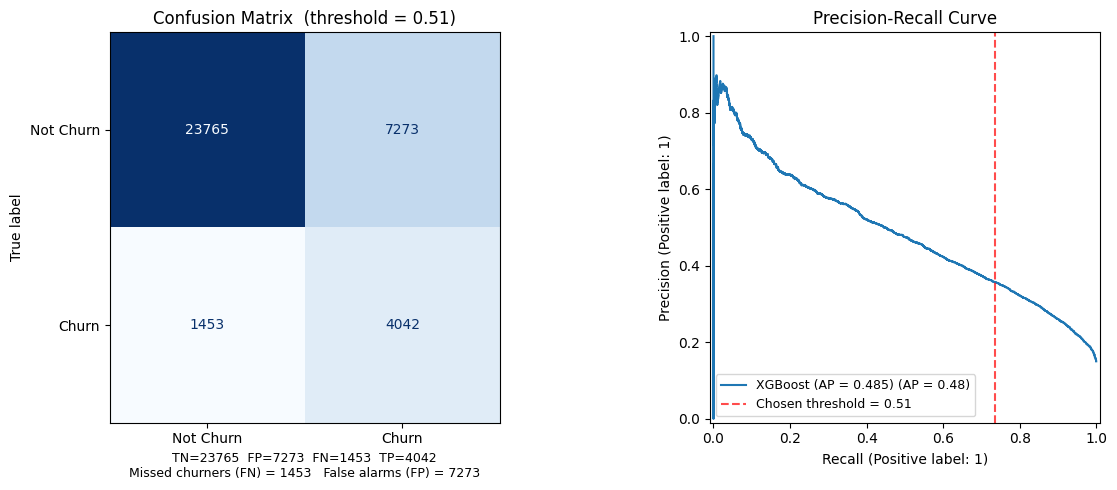

In [50]:
# ==============================
# NEW: CONFUSION MATRIX + PRECISION-RECALL CURVE
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (threshold = {best_threshold:.2f})')

tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Missed churners (FN) = {fn}   False alarms (FP) = {fp}',
    fontsize=9,
)

# --- Precision-Recall curve ---
ap = average_precision_score(y_test, y_probs)
PrecisionRecallDisplay.from_predictions(
    y_test, y_probs,
    name=f'XGBoost (AP = {ap:.3f})',
    ax=axes[1],
)
axes[1].axvline(
    x=xgb_rec, color='red', linestyle='--', alpha=0.7,
    label=f'Chosen threshold = {best_threshold:.2f}',
)
axes[1].legend(fontsize=9)
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## SHAP Feature Importance — Phase 9.2 (Explainability)

SHAP values explain *why* the model predicts churn for each customer. The bar plot shows global importance; the beeswarm shows the direction of each feature's effect.

In [55]:
!pip install --upgrade shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Top 15 features by mean |SHAP| (global importance):
calls_made           0.697035
sms_sent             0.516389
estimated_salary     0.339677
engagement_score     0.275950
avg_sms_per_day      0.191933
calls_vs_partner     0.126708
num_dependents       0.119501
avg_calls_per_day    0.106576
total_activity       0.070294
avg_data_per_day     0.031777
data_vs_partner      0.028697
tenure_days          0.018935
data_used            0.017930
calls_intensity      0.010102
high_value_user      0.008956


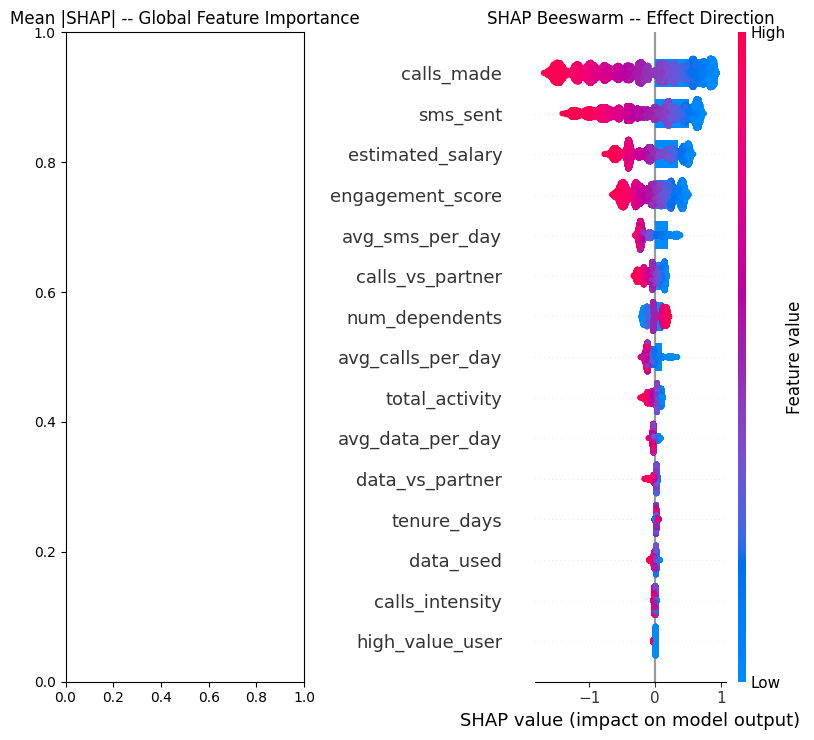

In [59]:
# ==============================
# NEW: SHAP FEATURE IMPORTANCE  (Phase 9.2 -- Explainability)
# ==============================
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
# shap_values: shape (n_test_samples, n_features)
# Positive value -> pushes prediction toward churn
# Negative value -> pushes prediction away from churn

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns,
).sort_values(ascending=False)

print("Top 15 features by mean |SHAP| (global importance):")
print(mean_abs_shap.head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot: mean absolute SHAP (overall importance)
shap.summary_plot(shap_values, X_test, plot_type='bar',
                   show=False, max_display=15)
axes[0].set_title('Mean |SHAP| -- Global Feature Importance')

# Beeswarm: direction of effect (red = high feature value, blue = low)
shap.summary_plot(shap_values, X_test,
                   show=False, max_display=15)
axes[1].set_title('SHAP Beeswarm -- Effect Direction')

plt.tight_layout()
plt.show()

In [61]:
# ==============================
# 14. SAVE ARTIFACTS
# ==============================
os.makedirs('models/v1', exist_ok=True)

joblib.dump(model,                 'models/v1/xgb_churn_model.pkl')
joblib.dump(le_dict,               'models/v1/label_encoders.pkl')
joblib.dump(best_threshold,        'models/v1/threshold.pkl')
joblib.dump(list(X_train.columns), 'models/v1/feature_columns.pkl')

# feature_thresholds now also includes partner_medians so the inference
# pipeline can reproduce the calls_vs_partner / data_vs_partner features
joblib.dump({
    'activity_thresh': activity_thresh,
    'salary_thresh':   salary_thresh,
    'partner_medians': partner_medians,
}, 'models/v1/feature_thresholds.pkl')

print("Artifacts saved to models/v1/")
print(f"  xgb_churn_model.pkl")
print(f"  label_encoders.pkl")
print(f"  threshold.pkl           -> {best_threshold}")
print(f"  feature_columns.pkl     -> {list(X_train.columns)}")
print(f"  feature_thresholds.pkl  -> includes partner_medians")

Artifacts saved to models/v1/
  xgb_churn_model.pkl
  label_encoders.pkl
  threshold.pkl           -> 0.5100000000000002
  feature_columns.pkl     -> ['telecom_partner', 'gender', 'age', 'state', 'city', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_days', 'total_activity', 'avg_data_per_day', 'avg_calls_per_day', 'avg_sms_per_day', 'engagement_score', 'low_activity_flag', 'high_value_user', 'partner_med_calls', 'partner_med_data', 'partner_med_sms', 'calls_vs_partner', 'data_vs_partner', 'is_new_customer', 'calls_intensity', 'data_intensity']
  feature_thresholds.pkl  -> includes partner_medians


In [63]:
# ==============================
# 15. MLFLOW EXPERIMENT LOGGING  (Phase 4)
# ==============================
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "file:./mlruns"))
mlflow.set_experiment("telecom-churn-phase4")

with mlflow.start_run(run_name="xgb_v2_tuned") as run:

    # Params
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("threshold",      best_threshold)
    mlflow.log_param("churn_label",    "logit_rebuilt")
    mlflow.log_param("split_strategy", "time_based_70_15_15")
    mlflow.log_param("n_features",     X_train.shape[1])

    # Metrics -- log baseline alongside XGB so runs are comparable
    mlflow.log_metric("baseline_auc", bl_auc)
    mlflow.log_metric("auc",          xgb_auc)
    mlflow.log_metric("f1",           xgb_f1)
    mlflow.log_metric("recall",       xgb_rec)
    mlflow.log_metric("precision",    xgb_prec)
    mlflow.log_metric("accuracy",     xgb_acc)
    mlflow.log_metric("auc_uplift",   xgb_auc - bl_auc)

    # Model + artifacts
    mlflow.xgboost.log_model(
        xgb_model=model,
        artifact_path="xgb_churn_model",
        registered_model_name="telecom-churn-xgb",
    )
    mlflow.log_artifact("models/v1/label_encoders.pkl")
    mlflow.log_artifact("models/v1/feature_thresholds.pkl")
    mlflow.log_artifact("models/v1/feature_columns.pkl")

    mlflow.set_tag("phase",  "4 - model_development")
    mlflow.set_tag("status", "tuned_with_optuna")

    run_id = run.info.run_id
    print(f"Run ID: {run_id}")

print("MLflow run logged.")

Traceback (most recent call last):
  File "C:\Users\a\Desktop\intership\MLOPS\myenv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "C:\Users\a\Desktop\intership\MLOPS\myenv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "C:\Users\a\Desktop\intership\MLOPS\myenv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "C:\Users\a\Desktop\intership\MLOPS\myenv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "C:\Users\a\Desktop\intership\MLOPS\myenv\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist."

Run ID: 06a87990e222463db6eab828c2a9ff28
MLflow run logged.


In [65]:
# ==============================
# 16. PROMOTE TO STAGING -> PRODUCTION
# ==============================
import mlflow.pyfunc
from mlflow.tracking import MlflowClient

client = MlflowClient()

latest_version = client.get_latest_versions(
    name="telecom-churn-xgb"
)[0].version

print(f"Latest model version: {latest_version}")

# Move to Staging
client.transition_model_version_stage(
    name="telecom-churn-xgb",
    version=latest_version,
    stage="Staging",
)
print(f"Version {latest_version} moved to Staging OK")

# Load and sanity-check from Staging before promoting
model_staged = mlflow.pyfunc.load_model(
    model_uri="models:/telecom-churn-xgb/Staging"
)
sample_preds = model_staged.predict(X_test.iloc[:5])
print("Sample predictions from Staging model:", sample_preds)
print("Actual labels:                        ", y_test.iloc[:5].values)

# Promote to Production
client.transition_model_version_stage(
    name="telecom-churn-xgb",
    version=latest_version,
    stage="Production",
)
print(f"Version {latest_version} is now in Production OK")

Latest model version: 3
Version 3 moved to Staging OK
Sample predictions from Staging model: [0 1 1 0 1]
Actual labels:                         [1 1 0 0 0]
Version 3 is now in Production OK
